In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
scam = pd.read_csv('spam_ham_dataset.csv')

In [97]:
scam.columns = ['Unnamed','label', 'email', 'class']

In [98]:
scam.head()

,Unnamed,label,email,class
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [99]:
scam.isnull().sum()

Unnamed    0
label      0
email      0
class      0
dtype: int64

In [100]:
scam.shape

(5171, 4)

In [101]:
li = [['ham','spam']]

In [102]:
from sklearn.preprocessing import OrdinalEncoder

In [103]:
oe = OrdinalEncoder(categories=li)  # Note the extra brackets around li
oe.fit(scam[['label']])

,categories,"[['ham', 'spam']]"
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [104]:
scam['label1'] = oe.transform(scam[['label']])
scam

,Unnamed,label,email,class,label1
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0,0.0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,0.0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,0.0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1,1.0
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0,0.0
...,...,...,...,...,...
5166,1518,ham,Subject: put the 10 on the ft\r\nthe transport...,0,0.0
5167,404,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0,0.0
5168,2933,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0,0.0
5169,1409,ham,Subject: industrial worksheets for august 2000...,0,0.0


In [105]:
scam.drop(columns = ['label'], inplace = True)

In [106]:
scam.head()

,Unnamed,email,class,label1
0,605,Subject: enron methanol ; meter # : 988291\r\n...,0,0.0
1,2349,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,0.0
2,3624,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,0.0
3,4685,"Subject: photoshop , windows , office . cheap ...",1,1.0
4,2030,Subject: re : indian springs\r\nthis deal is t...,0,0.0


In [107]:
scam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Unnamed  5171 non-null   int64  
 1   email    5171 non-null   object 
 2   class    5171 non-null   int64  
 3   label1   5171 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 161.7+ KB


In [108]:
scam.isnull().sum()

Unnamed    0
email      0
class      0
label1     0
dtype: int64

In [109]:
# For Text processing 
import nltk
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize

In [110]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')  # You likely need this for word_tokenize as well
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /home/hp/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/hp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/hp/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [188]:
stop_words = set(stopwords.words('english')) 
scam['email'] = scam['email'].apply(lambda x: ' '.join([ 
    word for word in word_tokenize(x)  
    if not word in stop_words]
))

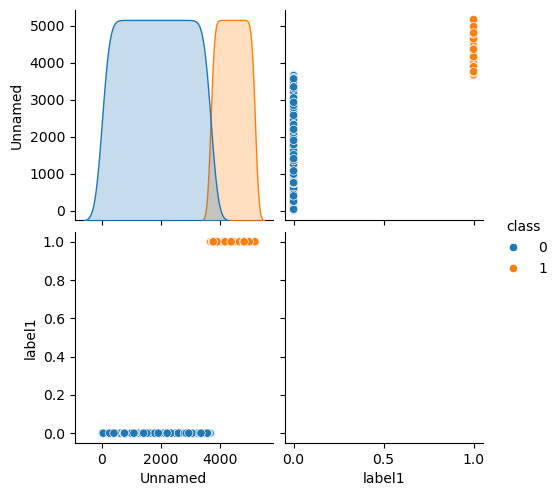

In [113]:
sns.pairplot(data =scam, hue = 'class')
plt.show()

In [147]:
X = scam.loc[:,'email']
y = scam['class'].values

In [148]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()

X=cv.fit_transform(X).toarray()

In [149]:
X[1]

array([0, 0, 0, ..., 0, 0, 0])

In [136]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [154]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 39)

In [155]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [160]:
lr.score(X_train, y_train)*100,lr.score(X_test, y_test)*100

(99.94473611494888, 97.9381443298969)

In [157]:
gb = GaussianNB()
gb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [162]:
gb.score(X_train, y_train)*100,gb.score(X_test, y_test)*100

(98.53550704614534, 96.32731958762886)

In [163]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [164]:
dt.score(X_train, y_train)*100,dt.score(X_test, y_test)*100

(100.0, 95.2963917525773)

In [171]:
y_pred = lr.predict(X_test)

In [168]:
from sklearn.metrics import confusion_matrix

In [172]:
confusion_matrix(y_test,y_pred)

array([[1072,   21],
       [  11,  448]])

In [174]:
cfm = confusion_matrix(y_test,y_pred)

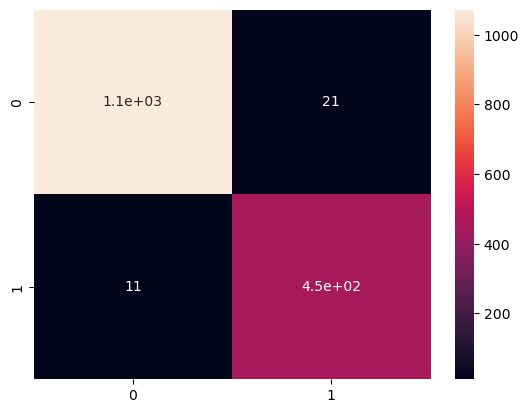

In [175]:
sns.heatmap(cfm, annot =True)
plt.show()

In [176]:
from sklearn.ensemble import VotingClassifier

In [179]:
lis = [('lr',LogisticRegression()),('dtc',DecisionTreeClassifier()),('gb',GaussianNB())]

In [180]:
vc = VotingClassifier(lis)
vc.fit(X_train, y_train)

,estimators,"[('lr', ...), ('dtc', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [181]:
vc.score(X_train, y_train)*100,vc.score(X_test, y_test)*100

(99.97236805747444, 98.38917525773195)

In [183]:
x_pred = vc.predict(X_test)

In [184]:
confusion_matrix(y_test, x_pred)

array([[1078,   15],
       [  10,  449]])

In [185]:
cfm = confusion_matrix(y_test, x_pred)

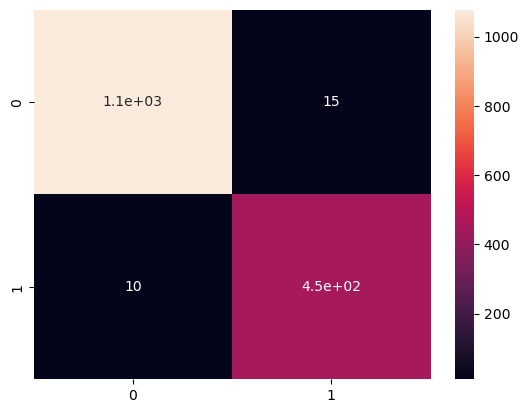

In [186]:
sns.heatmap(cfm, annot = True)
plt.show()